In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
sns.set(style="whitegrid")

INPUT_FOLDER = "prompts_sim_stats"

FILES = [
    "reasoning_prompt_similarity_stats.csv",
    "logical_prompt_similarity_stats.csv",
    "qna_prompt_similarity_stats.csv",
    "classification_prompt_similarity_stats.csv"
]

In [3]:
category_means = {}

# mean cossim vs prompt

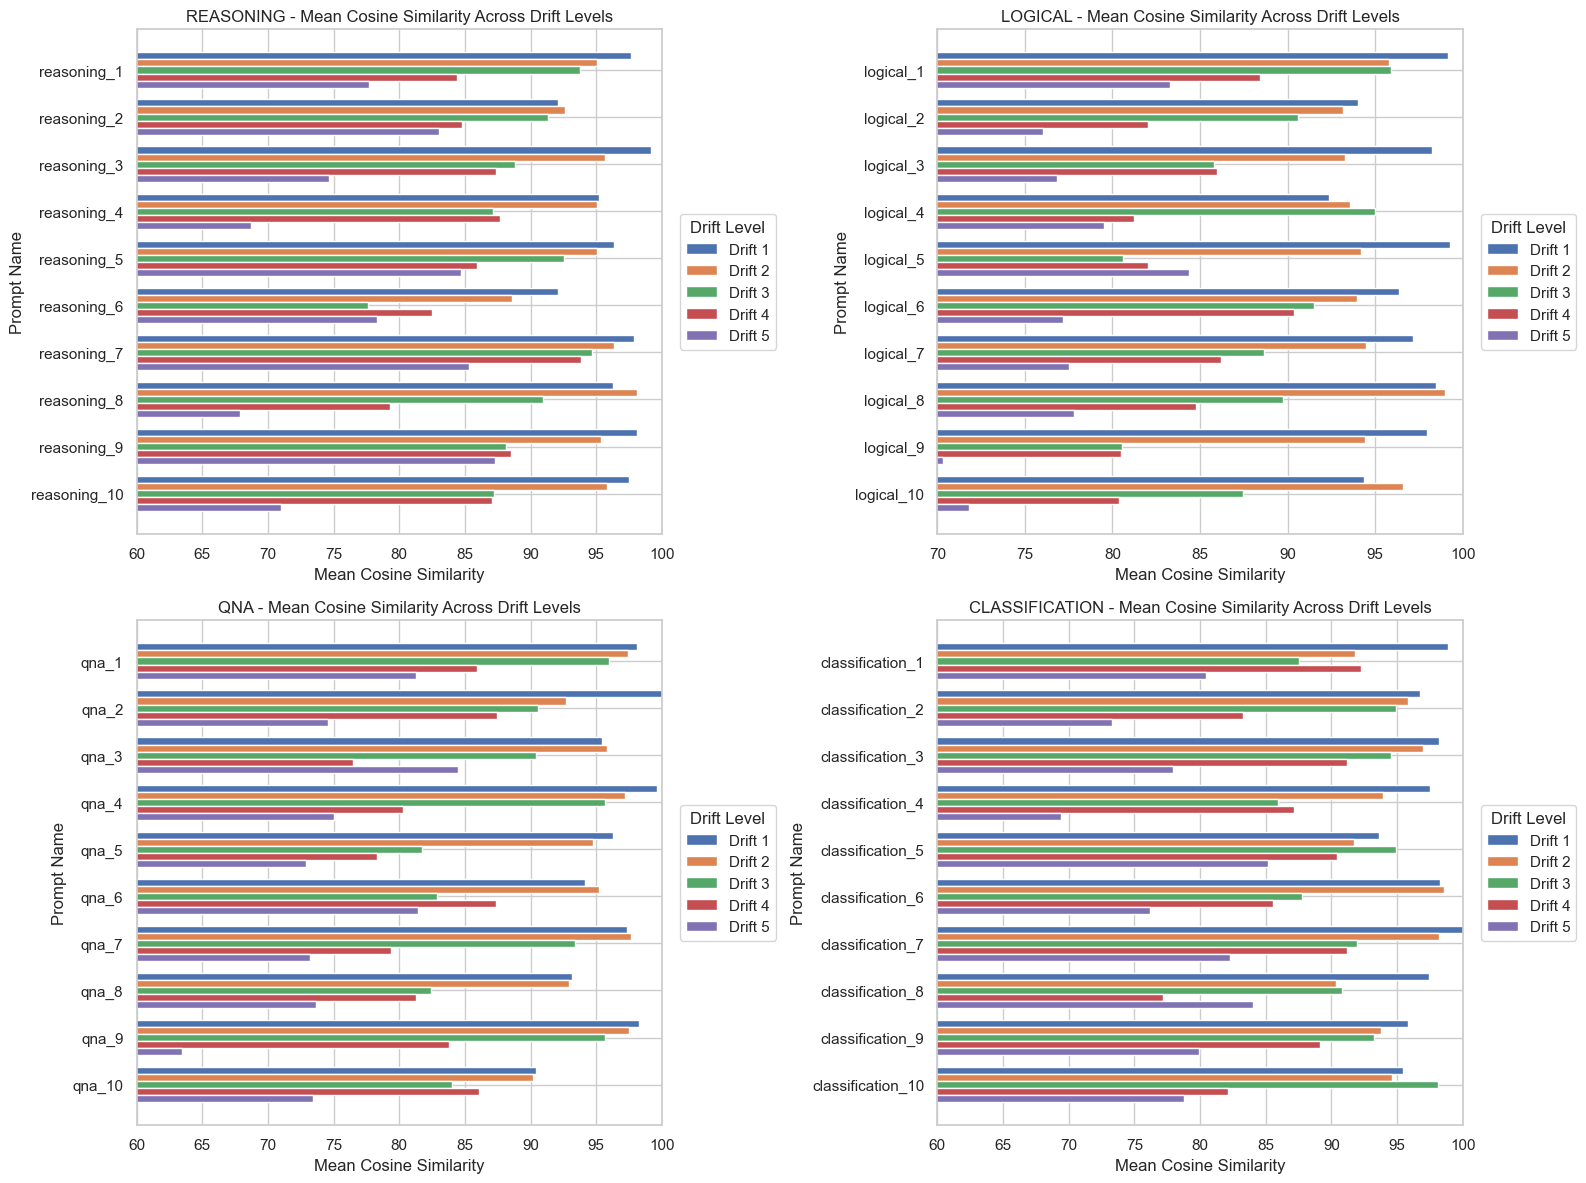

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, file in enumerate(FILES):

    ax = axes[idx]

    df = pd.read_csv(os.path.join(INPUT_FOLDER, file))
    category = file.split("_")[0]

    mean_cols = [col for col in df.columns 
                 if col.endswith("_mean") and "overall" not in col]

    prompt_names = [col.replace("_mean", "") for col in mean_cols]

    drift_levels = df["Drift/Variant"].values

    data_matrix = []
    for col in mean_cols:
        data_matrix.append(df[col].values)

    data_matrix = np.array(data_matrix)

    y_pos = np.arange(len(prompt_names))
    bar_height = 0.15

    for i in range(len(drift_levels)):
        ax.barh(
            y_pos + i * bar_height,
            data_matrix[:, i],
            height=bar_height,
            label=f"Drift {drift_levels[i]}"
        )

    ax.set_yticks(y_pos + bar_height * 2)
    ax.set_yticklabels(prompt_names)

    ax.set_xlabel("Mean Cosine Similarity")
    ax.set_ylabel("Prompt Name")
    ax.set_title(f"{category.upper()} - Mean Cosine Similarity Across Drift Levels")
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        title="Drift Level"
    )
    ax.invert_yaxis()

    min_val = (data_matrix.min() // 10) * 10
    ax.set_xlim(min_val, 100)
    

# Hide unused axes if <4 files
for i in range(len(FILES), len(axes)):
    fig.delaxes(axes[i])
    
plt.tight_layout(rect=[0,0,0.85,1])
plt.tight_layout()
plt.show()

# std vs prompt

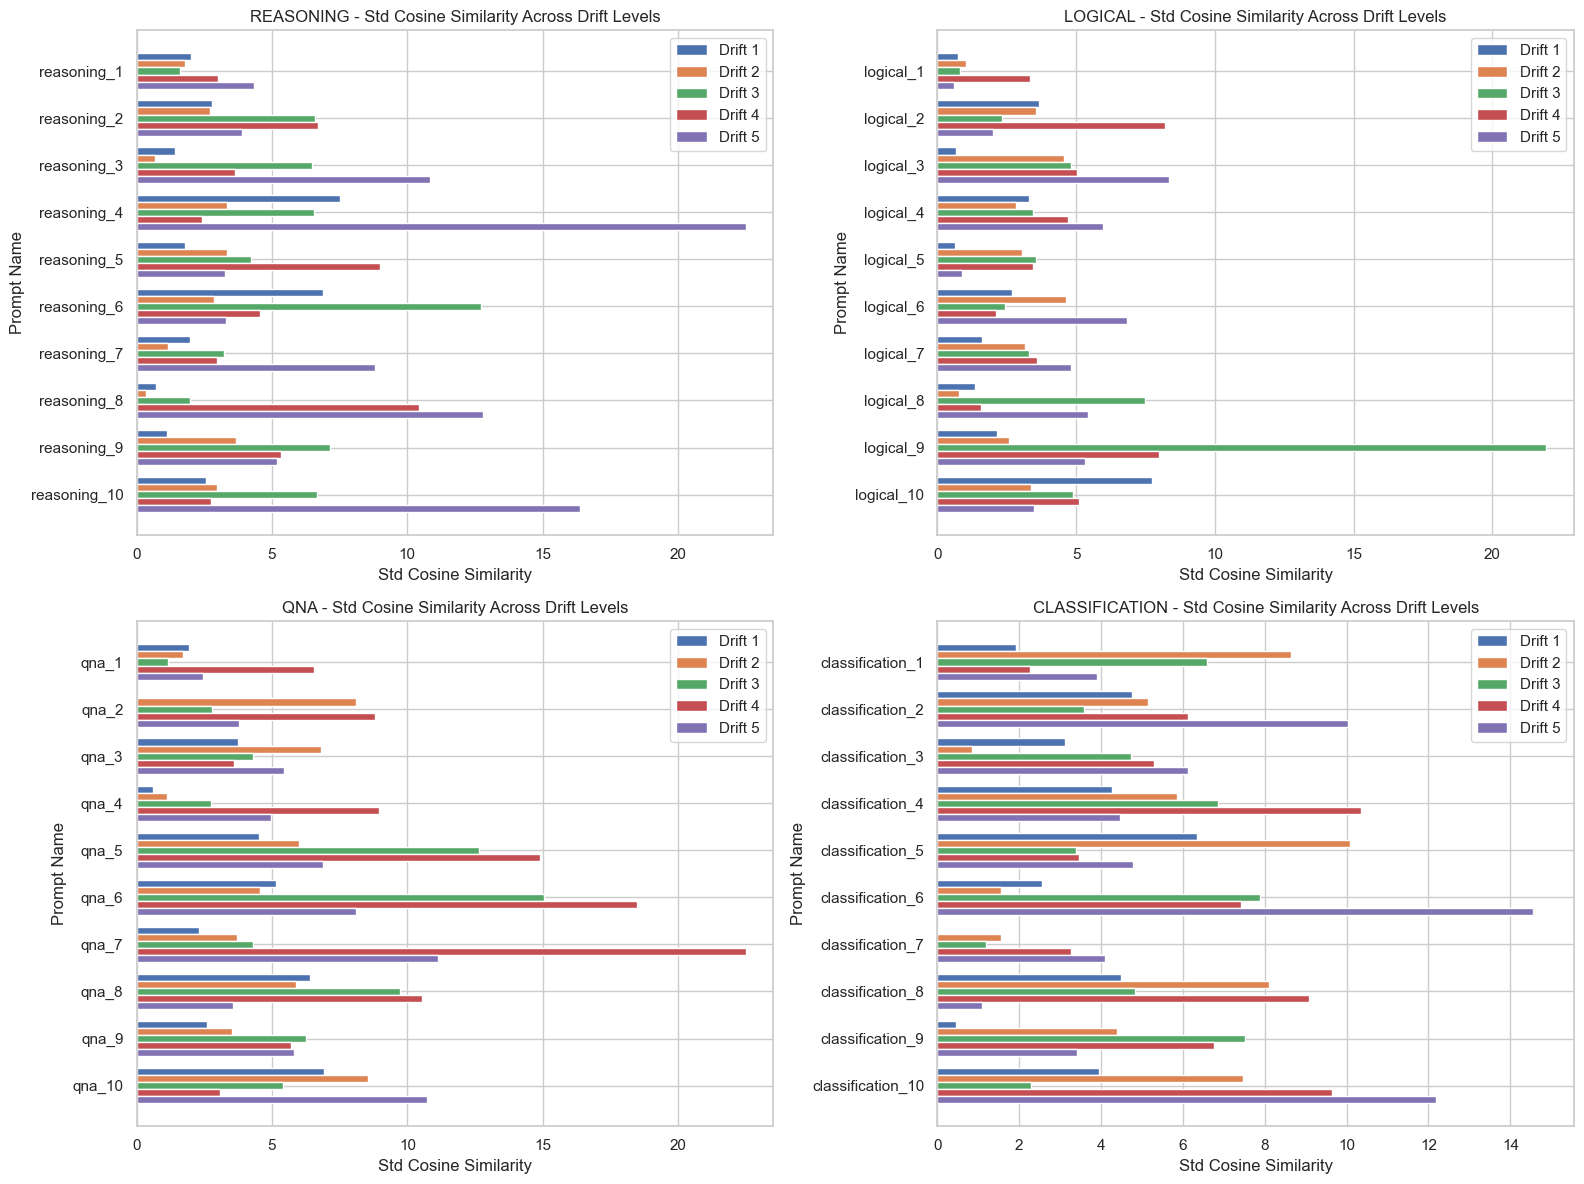

All combined category std plots generated on a single sheet.


In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, file in enumerate(FILES):

    ax = axes[idx]

    df = pd.read_csv(os.path.join(INPUT_FOLDER, file))
    category = file.split("_")[0]

    # Extract only prompt std columns
    std_cols = [col for col in df.columns
                if col.endswith("_std") and "overall" not in col]

    # Extract prompt names
    prompt_names = [col.replace("_std", "") for col in std_cols]

    drift_levels = df["Drift/Variant"].values

    # Prepare data matrix
    data_matrix = []
    for col in std_cols:
        data_matrix.append(df[col].values)

    data_matrix = np.array(data_matrix)

    # ==============================
    # Plot grouped horizontal bars
    # ==============================

    y_pos = np.arange(len(prompt_names))
    bar_height = 0.15

    for i in range(len(drift_levels)):
        ax.barh(
            y_pos + i * bar_height,
            data_matrix[:, i],
            height=bar_height,
            label=f"Drift {drift_levels[i]}"
        )

    ax.set_yticks(y_pos + bar_height * 2)
    ax.set_yticklabels(prompt_names)

    ax.set_xlabel("Std Cosine Similarity")
    ax.set_ylabel("Prompt Name")
    ax.set_title(f"{category.upper()} - Std Cosine Similarity Across Drift Levels")
    ax.legend()
    ax.invert_yaxis()

    min_val = (data_matrix.min() // 10) * 10
    ax.set_xlim(min_val, data_matrix.max() + 1)

# Hide unused subplots
for i in range(len(FILES), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

print("All combined category std plots generated on a single sheet.")

# general stats visualizations

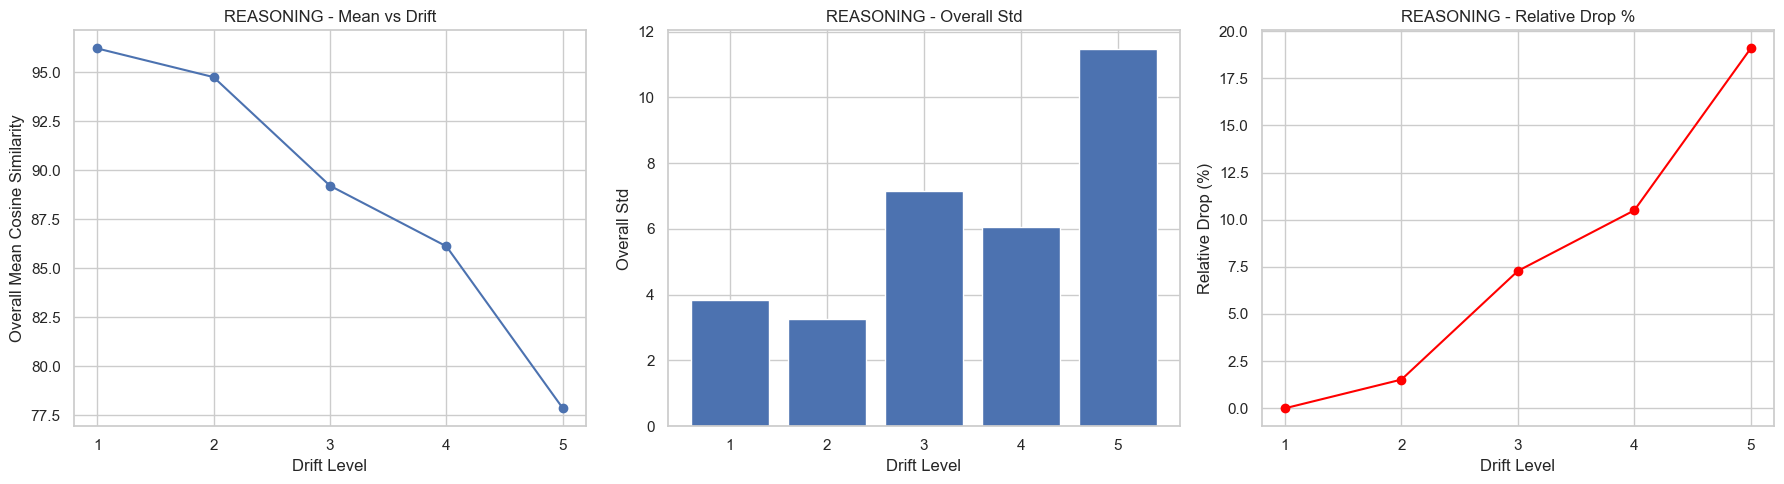

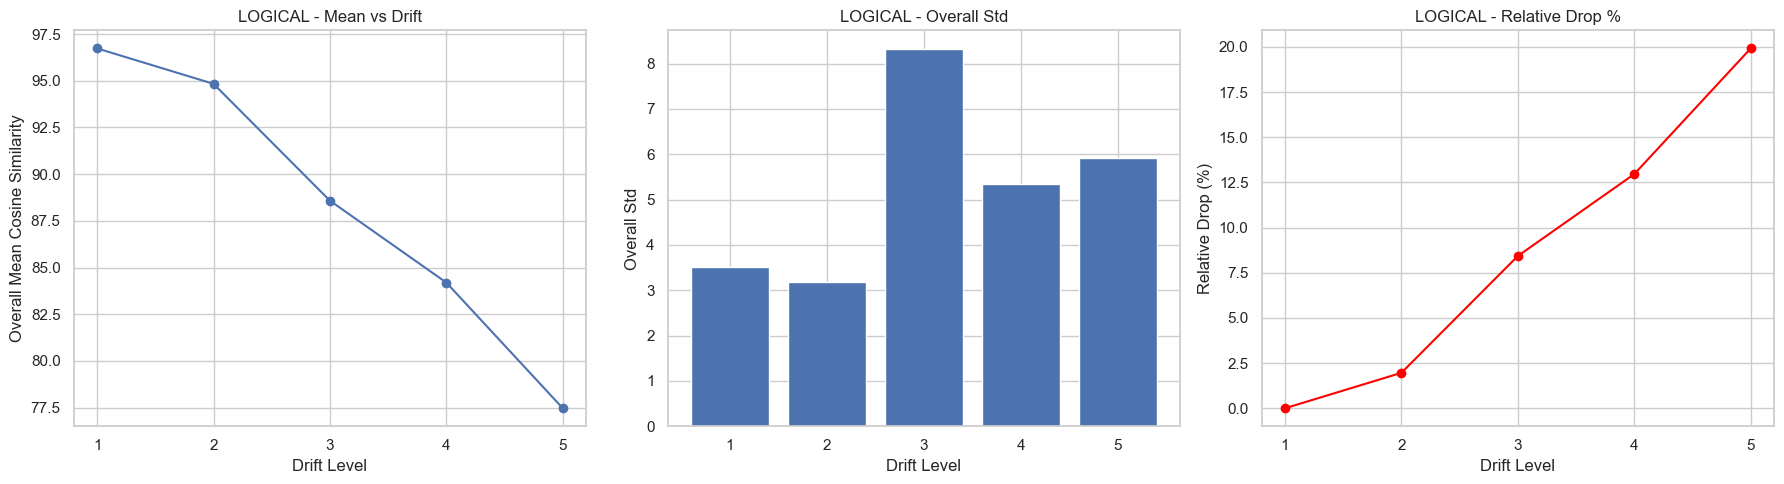

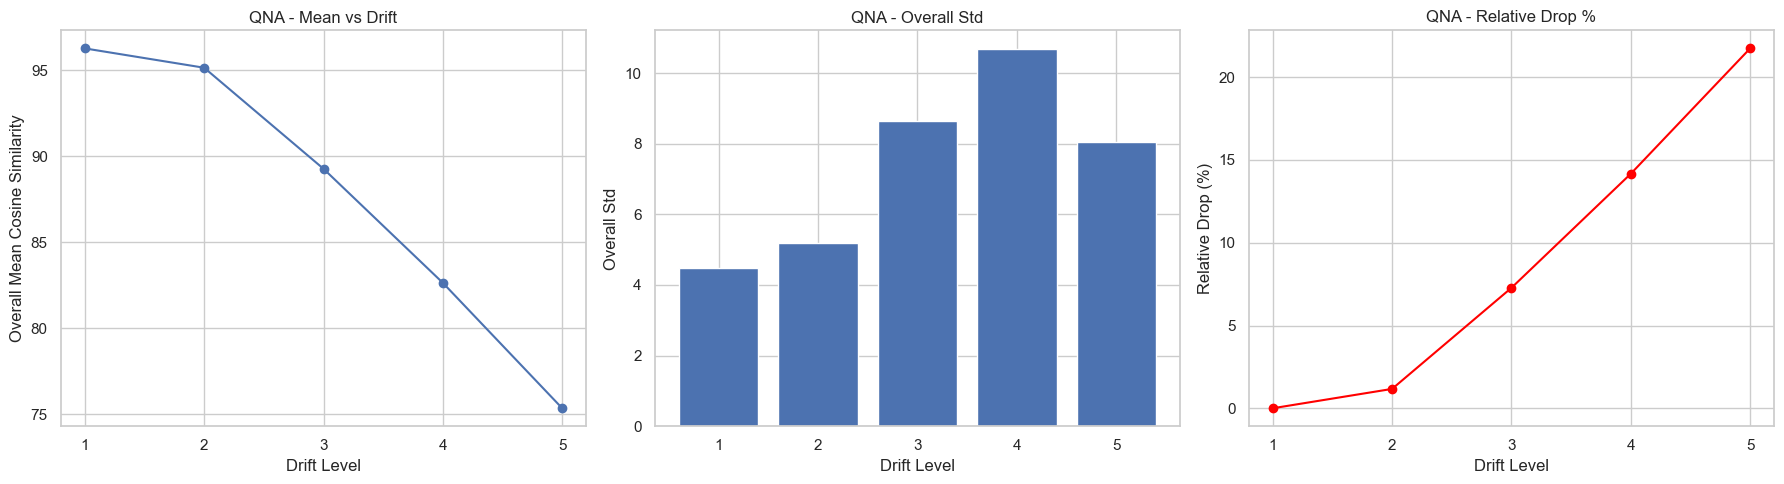

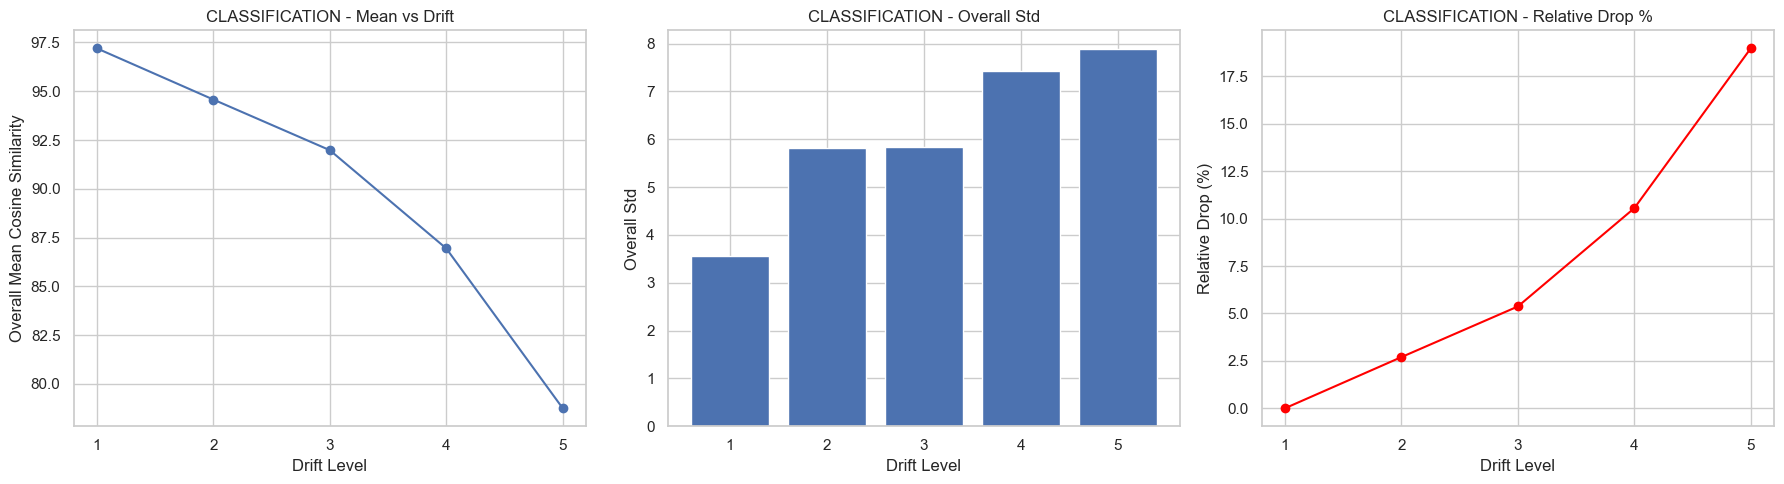

Category-wise plots generated.


In [24]:
for file in FILES:

    df = pd.read_csv(os.path.join(INPUT_FOLDER, file))
    category = file.split("_")[0]

    drift_levels = df["Drift/Variant"]

    # ----------------------------
    # Identify mean & std columns
    # ----------------------------
    mean_cols = [col for col in df.columns if col.endswith("_mean") and "overall" not in col]
    std_cols = [col for col in df.columns if col.endswith("_std") and "overall" not in col]

    # =========================================
    # Create ONE sheet with 3 plots
    # =========================================
    fig, axes = plt.subplots(1, 3, figsize=(18,5))

    # -----------------------------------------
    # 1️⃣ Mean vs Drift Level
    # -----------------------------------------
    axes[0].plot(drift_levels, df["overall_mean"], marker="o")
    axes[0].set_xlabel("Drift Level")
    axes[0].set_ylabel("Overall Mean Cosine Similarity")
    axes[0].set_title(f"{category.upper()} - Mean vs Drift")
    axes[0].set_xticks(drift_levels)

    # -----------------------------------------
    # 2️⃣ Overall Std
    # -----------------------------------------
    axes[1].bar(drift_levels, df["overall_std"])
    axes[1].set_xlabel("Drift Level")
    axes[1].set_ylabel("Overall Std")
    axes[1].set_title(f"{category.upper()} - Overall Std")

    # -----------------------------------------
    # 3️⃣ Relative Drop %
    # -----------------------------------------
    axes[2].plot(drift_levels, df["relative_drop_%"], marker="o", color="red")
    axes[2].set_xlabel("Drift Level")
    axes[2].set_ylabel("Relative Drop (%)")
    axes[2].set_title(f"{category.upper()} - Relative Drop %")
    axes[2].set_xticks(drift_levels)

    plt.tight_layout()
    plt.show()
    plt.close()

    # Save for combined plots
    category_means[category] = df["overall_mean"].values

print("Category-wise plots generated.")

# Combined Plot: Mean Cosine Similarity vs Drift

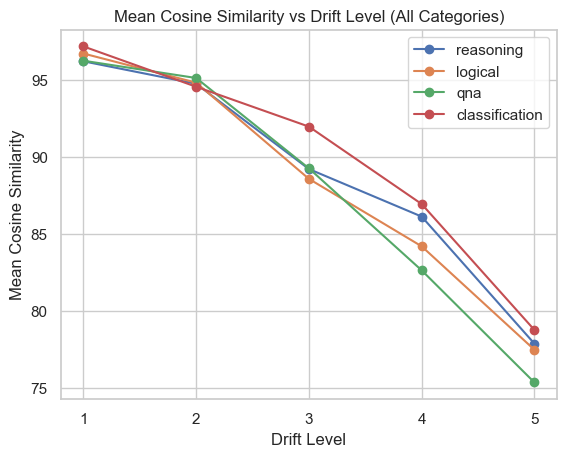

Combined mean plot generated.


In [26]:
plt.figure()

for category, values in category_means.items():
    plt.plot(range(1,6), values, marker="o", label=category)

plt.xlabel("Drift Level")
plt.ylabel("Mean Cosine Similarity")
plt.title("Mean Cosine Similarity vs Drift Level (All Categories)")
plt.xticks(range(1,6))
plt.legend()
plt.show()
plt.close()

print("Combined mean plot generated.")

# heatmap similarity

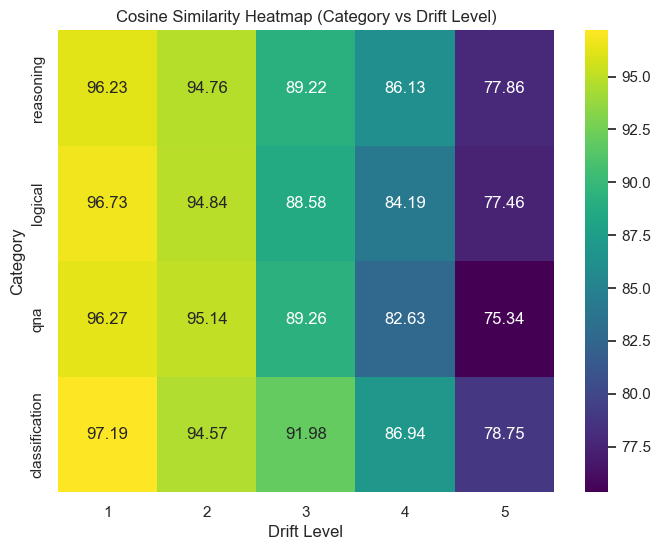

Heatmap generated.


In [27]:
heatmap_df = pd.DataFrame(category_means, index=[1,2,3,4,5])

plt.figure(figsize=(8,6))
sns.heatmap(heatmap_df.T, annot=True, cmap="viridis", fmt=".2f")

plt.xlabel("Drift Level")
plt.ylabel("Category")
plt.title("Cosine Similarity Heatmap (Category vs Drift Level)")

plt.show()
plt.close()

print("Heatmap generated.")